# The Moore-Penrose Pseudoinverse

The inverse of a matrix solves equations like $Ax = b$ when $A$ is square and invertible.

E. H. Moore and Roger Penrose developed the generalized inverse idea that now sits under least-squares fitting, signal processing, statistics, robotics, and machine learning. It lets linear algebra keep working when real data is noisy, overdetermined, or underdetermined.

Real data usually does not behave that nicely. In machine learning, $A$ is often rectangular: many rows of observations, fewer columns of features. A perfect solution may not exist, so the Moore-Penrose pseudoinverse $A^+$ gives the best least-squares answer.

<details>
<summary>Big idea</summary>

When $Ax=b$ cannot be solved exactly, $x=A^+b$ finds the vector that makes the error $\|Ax-b\|^2$ as small as possible.

</details>

## 1. Mental Model

A rectangular system usually has too many equations and too few unknowns.

For a line fit, every data point gives one equation:

$$
y_i \approx mx_i + b
$$

Stack those equations into matrix form:

$$
A\begin{bmatrix}m \\ b\end{bmatrix} \approx y
$$

The pseudoinverse gives the one-step best fit:

$$
\begin{bmatrix}m \\ b\end{bmatrix} = A^+y
$$

<details>
<summary>Least-squares hint</summary>

The line will not hit every noisy point. It minimizes the total squared vertical error across all points.

</details>

## 2. Build the Objects

We will keep the implementation small and inspectable:

- `DataPoint` stores one noisy observation.
- `SVDReport` records the singular values and numerical rank.
- `FitResult` stores the fitted line and residuals.
- `MoorePenroseSolver` builds $A^+$ from the SVD pieces.
- `LeastSquaresReplay` prints the important math steps.

<details>
<summary>SVD hint</summary>

SVD factors a matrix as $A = U\Sigma V^T$. The pseudoinverse flips the nonzero singular values: $A^+ = V\Sigma^+U^T$.

</details>

**Object model.** Define `DataPoint`, `SVDReport`, the named objects used by the next examples.


In [ ]:
from dataclasses import dataclass

import matplotlib.pyplot as plt

import numpy as np

@dataclass(frozen=True)
class DataPoint:
    feature: float
    target: float

@dataclass(frozen=True)
class SVDReport:
    singular_values: np.ndarray
    cutoff: float
    rank: int
    condition_number: float


**Object model.** Define `FitResult`, the named objects used by the next examples.


In [ ]:
@dataclass(frozen=True)
class FitResult:
    slope: float
    intercept: float
    predictions: np.ndarray
    residuals: np.ndarray
    mse: float
    report: SVDReport

    def equation(self) -> str:
        sign = "+" if self.intercept >= 0 else "-"
        return f"y = {self.slope:.3f}x {sign} {abs(self.intercept):.3f}"


**Algorithm engine.** Define `MoorePenroseSolver`, the class that runs the main simulation or algorithm.


In [ ]:
class MoorePenroseSolver:
    def __init__(self, rcond: float = 1e-12):
        self.rcond = rcond
        self.last_report: SVDReport | None = None

    def pseudoinverse(self, matrix: np.ndarray) -> np.ndarray:
        u, singular_values, vt = np.linalg.svd(matrix, full_matrices=False)
        largest = singular_values[0] if singular_values.size else 0.0
        cutoff = self.rcond * max(matrix.shape) * largest
        inverted = np.array([
            1 / value if value > cutoff else 0.0
            for value in singular_values
        ])
        rank = int(np.sum(singular_values > cutoff))
        condition_number = float(largest / singular_values[-1]) if singular_values[-1] > cutoff else float("inf")
        self.last_report = SVDReport(
            singular_values=singular_values,
            cutoff=cutoff,
            rank=rank,
            condition_number=condition_number,
        )
        return vt.T @ np.diag(inverted) @ u.T

    def solve(self, design_matrix: np.ndarray, targets: np.ndarray) -> np.ndarray:
        return self.pseudoinverse(design_matrix) @ targets


**Helper functions.** Define `design_matrix_from_points`, `targets_from_points`, `fit_line` so the later cells stay focused on behavior.


In [ ]:
def design_matrix_from_points(points: list[DataPoint]) -> np.ndarray:
    return np.array([[point.feature, 1.0] for point in points], dtype=float)

def targets_from_points(points: list[DataPoint]) -> np.ndarray:
    return np.array([point.target for point in points], dtype=float)

def fit_line(points: list[DataPoint], solver: MoorePenroseSolver) -> FitResult:
    design_matrix = design_matrix_from_points(points)
    targets = targets_from_points(points)
    slope, intercept = solver.solve(design_matrix, targets)
    predictions = design_matrix @ np.array([slope, intercept])
    residuals = targets - predictions
    mse = float(np.mean(residuals ** 2))
    if solver.last_report is None:
        raise RuntimeError("Solver did not produce an SVD report.")
    return FitResult(
        slope=float(slope),
        intercept=float(intercept),
        predictions=predictions,
        residuals=residuals,
        mse=mse,
        report=solver.last_report,
    )


## 3. Generate Noisy Data

We will create fake observations from a hidden line, then add noise.

The model is:

$$
y \approx mx + b
$$

The design matrix stores one row per data point: `[x, 1]`.

<details>
<summary>Machine learning connection</summary>

Linear regression is the first version of this idea: build a matrix of features, then solve for the weights that minimize prediction error.

</details>

In [2]:
rng = np.random.default_rng(7)
true_slope = 2.4
true_intercept = -1.3
x_values = np.linspace(-4, 6, 35)
noise = rng.normal(loc=0.0, scale=1.25, size=x_values.size)

points = [
    DataPoint(feature=float(x), target=float(true_slope * x + true_intercept + error))
    for x, error in zip(x_values, noise)
]

design_matrix = design_matrix_from_points(points)
targets = targets_from_points(points)

print(f"Design matrix shape: {design_matrix.shape}")
print(f"Target vector shape : {targets.shape}")
print("First five rows of A:")
print(design_matrix[:5])

Design matrix shape: (35, 2)
Target vector shape : (35,)
First five rows of A:
[[-4.          1.        ]
 [-3.70588235  1.        ]
 [-3.41176471  1.        ]
 [-3.11764706  1.        ]
 [-2.82352941  1.        ]]


## 4. Fit the Line with $A^+$

Now we solve in one step:

$$
\hat{x}=A^+y
$$

For a line, $\hat{x}$ contains the slope and intercept.

We will build $A^+$ ourselves from SVD pieces, then compare against `numpy.linalg.pinv()` only as a check.

In [3]:
solver = MoorePenroseSolver()
fit = fit_line(points, solver)

numpy_solution = np.linalg.pinv(design_matrix) @ targets
custom_solution = np.array([fit.slope, fit.intercept])

print(f"Hidden line       : y = {true_slope:.3f}x - {abs(true_intercept):.3f}")
print(f"Pseudoinverse fit: {fit.equation()}")
print(f"Mean squared error: {fit.mse:.3f}")
print()
print("Custom SVD-built solution:", custom_solution.round(6))
print("NumPy pinv solution       :", numpy_solution.round(6))
print("Difference norm           :", np.linalg.norm(custom_solution - numpy_solution))

Hidden line       : y = 2.400x - 1.300
Pseudoinverse fit: y = 2.332x - 1.774
Mean squared error: 1.038

Custom SVD-built solution: [ 2.332329 -1.77363 ]
NumPy pinv solution       : [ 2.332329 -1.77363 ]
Difference norm           : 0.0


## 5. Plot the Best-Fit Line

The fitted line is not drawn by a machine learning library. It comes directly from:

$$
A^+y
$$

The gray vertical segments are residuals: the prediction errors the least-squares solution tries to minimize.

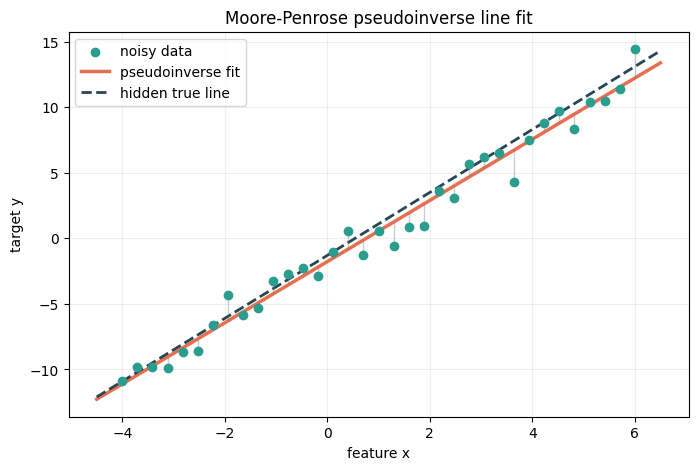

In [4]:
x_plot = np.linspace(x_values.min() - 0.5, x_values.max() + 0.5, 200)
y_fit = fit.slope * x_plot + fit.intercept
y_true = true_slope * x_plot + true_intercept

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_values, targets, color="#2A9D8F", label="noisy data", zorder=3)
ax.plot(x_plot, y_fit, color="#E76F51", linewidth=2.5, label="pseudoinverse fit")
ax.plot(x_plot, y_true, color="#264653", linestyle="--", linewidth=2, label="hidden true line")
ax.vlines(x_values, fit.predictions, targets, color="#6B7280", alpha=0.35, linewidth=1)
ax.set_title("Moore-Penrose pseudoinverse line fit")
ax.set_xlabel("feature x")
ax.set_ylabel("target y")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 6. Replay the Math

A good notebook should make the hidden matrix work visible. This replay summarizes what the solver saw: matrix shape, singular values, numerical rank, and residual error.

In [5]:
class LeastSquaresReplay:
    def __init__(self, design_matrix: np.ndarray, targets: np.ndarray, fit: FitResult):
        self.design_matrix = design_matrix
        self.targets = targets
        self.fit = fit

    def show(self) -> None:
        report = self.fit.report
        print(f"A shape: {self.design_matrix.shape[0]} rows x {self.design_matrix.shape[1]} columns")
        print(f"y shape: {self.targets.shape}")
        print(f"singular values: {np.round(report.singular_values, 4)}")
        print(f"numerical rank: {report.rank}")
        print(f"condition number: {report.condition_number:.3f}")
        print(f"solution: slope={self.fit.slope:.4f}, intercept={self.fit.intercept:.4f}")
        print(f"mean squared error: {self.fit.mse:.4f}")
        print(f"largest absolute residual: {np.max(np.abs(self.fit.residuals)):.4f}")


LeastSquaresReplay(design_matrix, targets, fit).show()

A shape: 35 rows x 2 columns
y shape: (35,)
singular values: [18.6478  5.5752]
numerical rank: 2
condition number: 3.345
solution: slope=2.3323, intercept=-1.7736
mean squared error: 1.0385
largest absolute residual: 2.4255


## 7. Experiment: Square, Tall, and Wide Matrices

The same pseudoinverse idea handles several matrix shapes:

- **Square**: behaves like an inverse when the inverse exists.
- **Tall**: finds the least-squares best fit.
- **Wide**: finds a minimum-norm solution when many answers are possible.

<details>
<summary>Shape hint</summary>

Tall means more rows than columns. Wide means more columns than rows.

</details>

In [6]:
def solve_system(name: str, matrix: np.ndarray, target: np.ndarray) -> None:
    experiment_solver = MoorePenroseSolver()
    solution = experiment_solver.solve(matrix, target)
    residual_norm = np.linalg.norm(matrix @ solution - target)
    report = experiment_solver.last_report
    if report is None:
        raise RuntimeError("Missing SVD report.")

    print(f"{name}")
    print(f"  shape: {matrix.shape}, rank: {report.rank}")
    print(f"  solution: {np.round(solution, 4)}")
    print(f"  residual norm: {residual_norm:.6f}")
    print()


square_matrix = np.array([[3.0, 1.0], [1.0, 2.0]])
square_target = np.array([8.0, 7.0])

wide_matrix = np.array([[1.0, 1.0, 1.0]])
wide_target = np.array([6.0])

solve_system("Square exact system", square_matrix, square_target)
solve_system("Tall noisy line-fit system", design_matrix, targets)
solve_system("Wide many-solution system", wide_matrix, wide_target)

Square exact system
  shape: (2, 2), rank: 2
  solution: [1.8 2.6]
  residual norm: 0.000000

Tall noisy line-fit system
  shape: (35, 2), rank: 2
  solution: [ 2.3323 -1.7736]
  residual norm: 6.028790

Wide many-solution system
  shape: (1, 3), rank: 1
  solution: [2. 2. 2.]
  residual norm: 0.000000



## 8. Playground: More Noise, Less Certainty

The pseudoinverse always gives the least-squares best line for the data it receives. If the data becomes noisier, the fitted line still exists, but the error grows.

**Builder helper.** Define `make_noisy_line`, which prepares reusable examples or traces.


In [ ]:
def make_noisy_line(noise_scale: float, seed: int) -> tuple[list[DataPoint], FitResult]:
    local_rng = np.random.default_rng(seed)
    local_noise = local_rng.normal(0.0, noise_scale, size=x_values.size)
    local_points = [
        DataPoint(float(x), float(true_slope * x + true_intercept + error))
        for x, error in zip(x_values, local_noise)
    ]
    local_fit = fit_line(local_points, MoorePenroseSolver())
    return local_points, local_fit

noise_levels = [0.25, 1.25, 3.0]

noise_results = []

for index, noise_level in enumerate(noise_levels):
    experiment_points, experiment_fit = make_noisy_line(noise_level, seed=20 + index)
    noise_results.append((noise_level, experiment_points, experiment_fit))
    print(
        f"noise={noise_level:<4} {experiment_fit.equation():<18} "
        f"mse={experiment_fit.mse:.3f}"
    )

fig, axes = plt.subplots(1, len(noise_results), figsize=(15, 4), sharey=True)


**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
for ax, (noise_level, experiment_points, experiment_fit) in zip(axes, noise_results):
    local_x = np.array([point.feature for point in experiment_points])
    local_y = np.array([point.target for point in experiment_points])
    ax.scatter(local_x, local_y, color="#2A9D8F", s=28)
    ax.plot(x_plot, experiment_fit.slope * x_plot + experiment_fit.intercept, color="#E76F51", linewidth=2)
    ax.plot(x_plot, y_true, color="#264653", linestyle="--", linewidth=1.8)
    ax.set_title(f"noise={noise_level}")
    ax.grid(alpha=0.2)

plt.tight_layout()

plt.show()


## 9. Sanity Check: The Penrose Conditions

The Moore-Penrose pseudoinverse is not just any approximate inverse. It satisfies special identities. Two useful checks are:

$$
AA^+A = A
$$

and

$$
A^+AA^+ = A^+
$$

In [8]:
identity_solver = MoorePenroseSolver()
a_plus = identity_solver.pseudoinverse(design_matrix)

check_one = np.allclose(design_matrix @ a_plus @ design_matrix, design_matrix)
check_two = np.allclose(a_plus @ design_matrix @ a_plus, a_plus)

print(f"A @ A_plus @ A equals A: {check_one}")
print(f"A_plus @ A @ A_plus equals A_plus: {check_two}")
print(f"A shape     : {design_matrix.shape}")
print(f"A_plus shape: {a_plus.shape}")

A @ A_plus @ A equals A: True
A_plus @ A @ A_plus equals A_plus: True
A shape     : (35, 2)
A_plus shape: (2, 35)


## 10. What You Should Remember

- A normal inverse only works for square, invertible matrices.
- Real data often creates rectangular systems with no perfect exact solution.
- The Moore-Penrose pseudoinverse gives the least-squares best solution.
- SVD lets us build $A^+$ by flipping nonzero singular values.
- `numpy.linalg.pinv()` uses this idea, but you now know the math shape behind it.

<details>
<summary>Course connection</summary>

This lesson bridges pure linear algebra and practical machine learning: a noisy scatter plot becomes a matrix problem, and the best-fit model appears from one matrix multiply.

</details>

## Visual Trace + Rigor Studio

**Problem frame.** Solve imperfect linear systems with least-squares structure.

**Interactive animation target.** Animate projection onto column space and singular-value filtering.

**Correctness handle.** The pseudoinverse solution minimizes residual norm and, when underdetermined, solution norm.

**Complexity handle.** SVD-based methods are typically O(min(mn^2, m^2n)) for an m by n matrix.

**Failure mode to test.** Tiny singular values amplify noise unless regularized or truncated.

**Studio task.** Perturb a nearly singular matrix and explain how the solution changes.


In [ ]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, AlgorithmTrace, TraceStep, render_trace_table

# Convert the implementation above into snapshots:
# trace = AlgorithmTrace("Topic trace")
# trace.append("start", {"your_state": ...}, "What changed?", invariant="What remains true?")
# AlgorithmPlayer(trace, your_renderer).display()
print("Use AlgorithmTrace to turn this notebook's algorithm into a step-by-step visual player.")
